In [10]:
from scripts.csv_continue_to_ds_discreet import csv_continue_to_ds_discreet
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from scripts.evaluate_model import evaluate_predictions

In [11]:
X, y = csv_continue_to_ds_discreet()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

In [13]:
model = Pipeline([
    ('rf', RandomForestClassifier(random_state=0, n_jobs=-1, class_weight='balanced'))
])

In [14]:
params = {
  'rf__n_estimators': [100, 200, 300],
  'rf__max_depth': [2,3,4],
  'rf__min_samples_split': [2, 5, 10],
  'rf__min_samples_leaf': [1, 2, 4],
  'rf__max_features': ['auto', 'sqrt', 'log2']
}


cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(model, param_grid=params, cv=cv_stratified, scoring='roc_auc', n_jobs=-1)

In [15]:
gs.fit(X_train, y_train)

c:\Users\David\Desktop\studio\data_analisys\kaggle\studio_data_science\000-in-evidenza\02-stroke\.venv-stroke\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
405 fits failed out of a total of 1215.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
234 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\David\Desktop\studio\data_analisys\kaggle\studio_data_science\000-in-evidenza\02-stroke\.venv-stroke\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\David\Desktop\studio\data_analisys\kaggle\studio_data_science\000-in-evidenza\02-stroke\.venv-stroke\Lib\site-packages\

,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'rf__max_depth': [2, 3, ...], 'rf__max_features': ['auto', 'sqrt', ...], 'rf__min_samples_leaf': [1, 2, ...], 'rf__min_samples_split': [2, 5, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [16]:
(f'best_score: {gs.best_score_}; best_params: {gs.best_params_}')

"best_score: 0.8213099786895441; best_params: {'rf__max_depth': 3, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}"

In [17]:
def evaluate_on_train_test(model, X_train, y_train, X_test, y_test):
    print(f"Evaluating train data")
    train_predictions = model.predict(X_train)
    train_probas = model.predict_proba(X_train)
    evaluate_predictions(train_predictions, y_train, train_probas[:, 1])
    
    print("Evaluating on test data")
    
    test_predictions = model.predict(X_test)
    test_probas = model.predict_proba(X_test)
    evaluate_predictions(test_predictions, y_test, test_probas[:, 1])


Evaluating train data


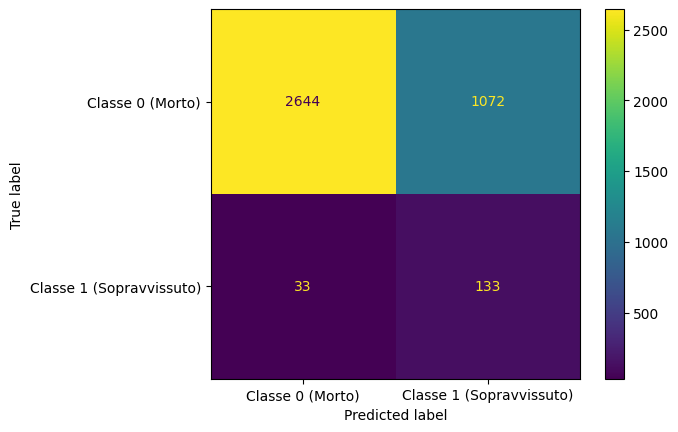

Percentuale di veri negativi: 71.15%
Percentuale di veri positivi: 80.12%
                          precision    recall  f1-score   support

        Classe 0 (Morto)       0.99      0.71      0.83      3716
Classe 1 (Sopravvissuto)       0.11      0.80      0.19       166

                accuracy                           0.72      3882
               macro avg       0.55      0.76      0.51      3882
            weighted avg       0.95      0.72      0.80      3882

[[2644 1072]
 [  33  133]]


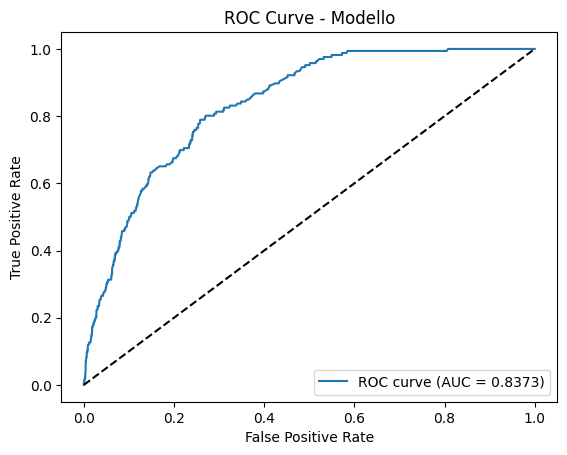

Evaluating on test data


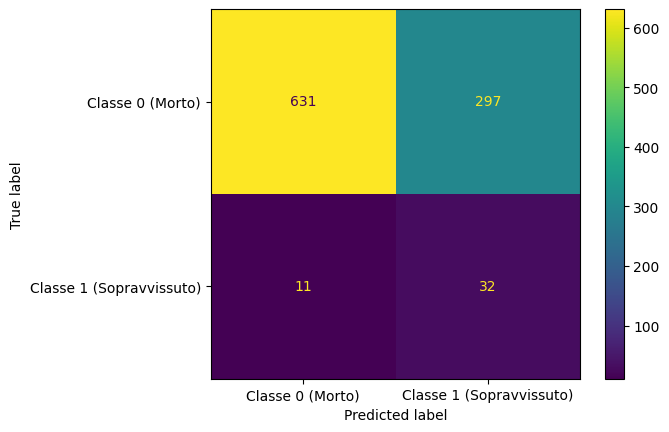

Percentuale di veri negativi: 68.00%
Percentuale di veri positivi: 74.42%
                          precision    recall  f1-score   support

        Classe 0 (Morto)       0.98      0.68      0.80       928
Classe 1 (Sopravvissuto)       0.10      0.74      0.17        43

                accuracy                           0.68       971
               macro avg       0.54      0.71      0.49       971
            weighted avg       0.94      0.68      0.78       971

[[631 297]
 [ 11  32]]


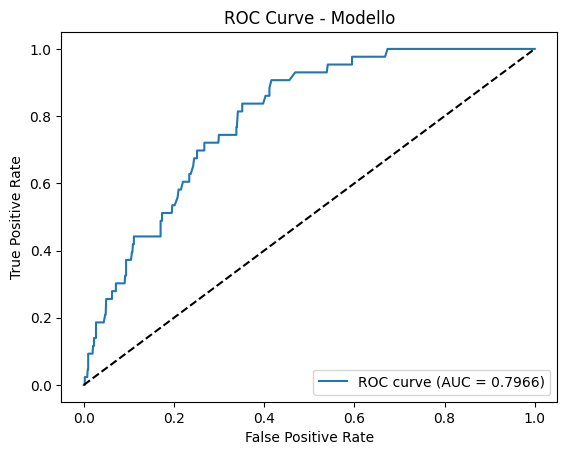

In [18]:
evaluate_on_train_test(gs.best_estimator_, X_train, y_train, X_test, y_test)